## LINK VIDEO GOOGLE DRIVE

https://drive.google.com/file/d/1fQnTtaA-q49GIs_OCWuEURm6o9QOu78I/view?usp=sharing

# Soal 2: Dimension Reduction dengan Autoencoder
Dataset yang digunakan: **Car** dan **Plane**

## 2a. Loading Data, Scaling, dan Pembagian Dataset

Pada bagian ini:
1. Load gambar dari folder training/car, training/plane, testing/car, testing/plane
2. Melakukan scaling (normalisasi pixel ke rentang [0, 1])
3. Menampilkan contoh gambar dari masing-masing kelas
4. Membagi dataset menjadi: **80% training set, 10% validation set, 10% test set**

In [ ]:
# IMPORT LIBRARIES
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from skimage.metrics import structural_similarity as ssim

np.random.seed(42)
tf.random.set_seed(42)

print('Libraries imported successfully!')
print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Libraries imported successfully!
PyTorch version: 2.11.0+cpu
Device: cpu


code ini untuk mengimpor semua library yang dibutuhkan, mencakup os dan numpy untuk operasi file dan array numerik, matplotlib untuk visualisasi, PIL.Image untuk membaca file gambar dari disk, train_test_split dari Scikit-learn untuk pembagian dataset, seluruh modul PyTorch yang diperlukan (nn, optim, DataLoader, TensorDataset) untuk membangun dan melatih model deep learning, serta structural_similarity dari skimage.metrics sebagai metrik evaluasi kualitas rekonstruksi gambar.

lalu, output menunjukkan Device adalah cpu, berarti tidak ada GPU yang tersedia dan seluruh komputasi berjalan di CPU.

In [ ]:
import zipfile

with zipfile.ZipFile('/content/deepLearningDataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [ ]:
!find /content -type d | grep overhead

/content/__MACOSX/deepLearningDataset/overhead
/content/__MACOSX/deepLearningDataset/overhead/testing
/content/__MACOSX/deepLearningDataset/overhead/testing/plane
/content/__MACOSX/deepLearningDataset/overhead/testing/parking_lot
/content/__MACOSX/deepLearningDataset/overhead/testing/ship
/content/__MACOSX/deepLearningDataset/overhead/testing/storage_tank
/content/__MACOSX/deepLearningDataset/overhead/testing/harbor
/content/__MACOSX/deepLearningDataset/overhead/testing/oil_gas_field
/content/__MACOSX/deepLearningDataset/overhead/testing/helicopter
/content/__MACOSX/deepLearningDataset/overhead/testing/car
/content/__MACOSX/deepLearningDataset/overhead/testing/stadium
/content/__MACOSX/deepLearningDataset/overhead/testing/runway_mark
/content/__MACOSX/deepLearningDataset/overhead/training
/content/__MACOSX/deepLearningDataset/overhead/training/plane
/content/__MACOSX/deepLearningDataset/overhead/training/parking_lot
/content/__MACOSX/deepLearningDataset/overhead/training/ship
/content/

code ini mengekstrak file zip dataset (deepLearningDataset.zip) ke direktori /content/ menggunakan modul zipfile, kemudian menampilkan seluruh struktur direktori, tujuannya adalah memastikan file berhasil diekstrak dengan benar

Output menunjukkan bahwa dataset memiliki dua level folder utama yaitu training dan testing, masing-masing berisi 10 subkelas (plane, parking_lot, ship, storage_tank, harbor, oil_gas_field, helicopter, car, stadium, runway_mark), namun untuk project ini hanya dua kelas yang akan digunakan yaitu car dan plane.

In [ ]:
# LOAD IMAGES DARI FOLDER
def load_images_from_folder(folder_path, label):
    """Load semua gambar .jpg dari folder, return array numpy dan label."""
    images = []
    labels = []
    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith('.jpg') or filename.endswith('.png'):
            img_path = os.path.join(folder_path, filename)
            img = Image.open(img_path).convert('L')  # grayscale
            img_array = np.array(img, dtype=np.float32)
            images.append(img_array)
            labels.append(label)
    return np.array(images), np.array(labels)

BASE_PATH = '/content/deepLearningDataset/overhead'

# Load training data
X_car_train, y_car_train     = load_images_from_folder(os.path.join(BASE_PATH, 'training', 'car'), label=0)
X_plane_train, y_plane_train = load_images_from_folder(os.path.join(BASE_PATH, 'training', 'plane'), label=1)

# Load testing data
X_car_test, y_car_test       = load_images_from_folder(os.path.join(BASE_PATH, 'testing', 'car'), label=0)
X_plane_test, y_plane_test   = load_images_from_folder(os.path.join(BASE_PATH, 'testing', 'plane'), label=1)

# Gabungkan training + testing dari folder, lalu split manual 80/10/10
X_all = np.concatenate([X_car_train, X_plane_train, X_car_test, X_plane_test], axis=0)
y_all = np.concatenate([y_car_train, y_plane_train, y_car_test, y_plane_test], axis=0)

print(f'Total data: {X_all.shape[0]} gambar')
print(f'  - Car   : {np.sum(y_all==0)} gambar')
print(f'  - Plane : {np.sum(y_all==1)} gambar')
print(f'Ukuran gambar: {X_all.shape[1]}x{X_all.shape[2]} piksel (grayscale)')

Total data: 2000 gambar
  - Car   : 1000 gambar
  - Plane : 1000 gambar
Ukuran gambar: 28x28 piksel (grayscale)


code ini mendefinisikan fungsi load_images_from_folder yang memuat semua file .jpg atau .png dari sebuah folder, mengkonversi setiap gambar ke mode grayscale, mengubahnya menjadi array NumPy bertipe float32, lalu mengumpulkan semua gambar dan label ke dalam list yang akhirnya dikembalikan sebagai array. Fungsi ini dipanggil empat kali, yaitu dua kali untuk memuat data training car dan plane, dua kali lagi untuk data testing car dan plane dari folder. Setelah semua data dimuat, keempatnya digabungkan menjadi satu array besar menggunakan np.concatenate, alasannya adalah dataset akan dibagi ulang secara manual dengan rasio 80/10/10, sehingga pembagian bawaan dari Kaggle diabaikan. Output akhir mengkonfirmasi total 2.000 gambar berhasil dimuat dengan distribusi yang seimbang (1.000 Car dan 1.000 Plane), masing-masing berukuran 28x28 piksel dalam grayscale.

In [ ]:
# SCALING (NORMALISASI) DAN FLATTEN
# Normalisasi pixel ke [0, 1]
X_all_norm = X_all / 255.0

# Flatten: 28x28 -> 784 (untuk Autoencoder Dense)
X_flat = X_all_norm.reshape(-1, 784)

print(f'Shape setelah flatten: {X_flat.shape}')  # (N, 784)
print(f'Nilai min: {X_flat.min():.4f}, max: {X_flat.max():.4f}')

Shape setelah flatten: (2000, 784)
Nilai min: 0.0000, max: 1.0000


code ini menjalankan tiga tahap pre proses sekaligus secara berurutan.

Pertama, normalisasi dilakukan dengan membagi seluruh nilai piksel dengan 255.0 sehingga rentang nilai berubah dari [0, 255] menjadi [0.0, 1.0], ini agar skala input konsisten dan proses optimasi neural network lebih stabil.

Kedua, gambar di-flatten dari bentuk 2D (28x28) menjadi vektor 1D sepanjang 784 menggunakan .reshape(-1, 784), yang merupakan format yang dibutuhkan oleh layer Fully Connected pada baseline autoencoder, meskipun nantinya di DataLoader akan di reshape ulang ke (1, 28, 28) untuk layer konvolusi.

Ketiga, dataset dibagi dua tahap menggunakan train_test_split dengan stratify=y_all untuk memastikan proporsi kelas Car dan Plane tetap seimbang di setiap split.

In [ ]:
# SPLIT DATA: 80% TRAIN, 10% VALIDATION, 10% TEST
# Step 1: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_flat, y_all, test_size=0.20, random_state=42, stratify=y_all
)
# Step 2: Split 20% temp -> 10% val, 10% test (50-50)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Training set  : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X_flat)*100:.1f}%)')
print(f'Validation set: {X_val.shape[0]} sampel ({X_val.shape[0]/len(X_flat)*100:.1f}%)')
print(f'Test set      : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X_flat)*100:.1f}%)')

Training set  : 1600 sampel (80.0%)
Validation set: 200 sampel (10.0%)
Test set      : 200 sampel (10.0%)


tahap pertama memisahkan 80% sebagai train dan 20% sebagai temp, lalu tahap kedua membelah temp menjadi dua bagian sama rata sehingga menghasilkan 10% validasi dan 10% test. Output tsb menunjukkan bahwa pembagian berjalan sesuai, yaitu 1.600 sampel train, 200 sampel validasi, dan 200 sampel test.

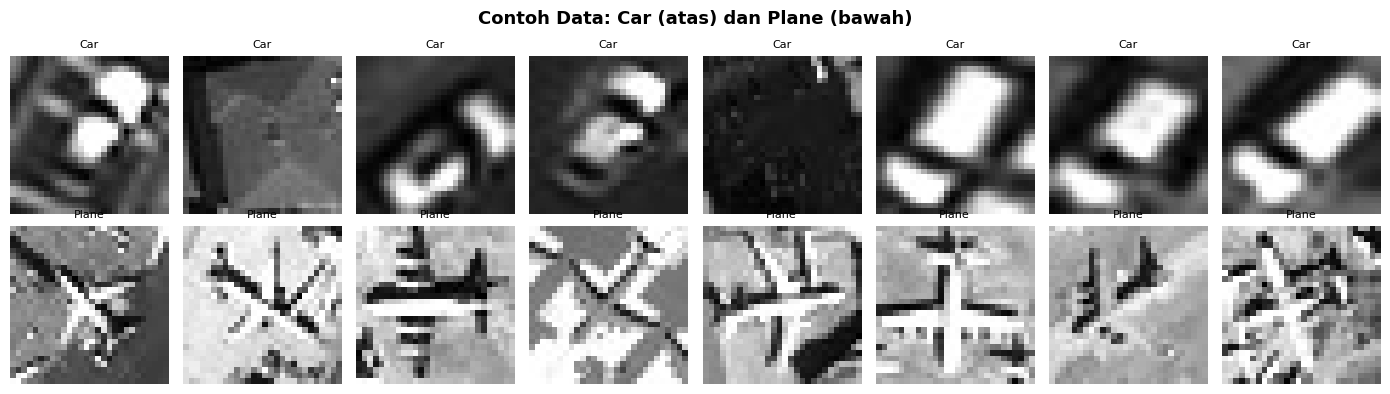

Contoh gambar dari dataset Overhead-MNIST (Car dan Plane)


In [ ]:
# TAMPILKAN CONTOH DATA
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Contoh Data: Car (atas) dan Plane (bawah)', fontsize=13, fontweight='bold')

car_indices   = np.where(y_all == 0)[0][:8]
plane_indices = np.where(y_all == 1)[0][:8]

for i, idx in enumerate(car_indices):
    axes[0, i].imshow(X_all_norm[idx], cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('Car', fontsize=8)

for i, idx in enumerate(plane_indices):
    axes[1, i].imshow(X_all_norm[idx], cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('Plane', fontsize=8)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('Contoh gambar dari dataset Overhead-MNIST (Car dan Plane)')

code ini membuat grid visualisasi 2x8 yang menampilkan 8 contoh gambar car di baris atas dan 8 contoh gambar plane di baris bawah, semuanya ditampilkan dalam skala grayscale menggunakan cmap='gray'. Tujuannya adalah melakukan inspeksi visual awal terhadap data untuk memahami karakteristik gambar sebelum masuk ke pemodelan, apakah gambarnya udah bersih, bagaimana variasinya, dan apakah dua kelas tersebut secara visual cukup berbeda untuk dipelajari oleh model.

Output menunjukkan gambar-gambar berukuran kecil 28x28 piksel dengan berbagai orientasi. mobil tampak sebagai objek persegi,  sementara itu pesawat terlihat sebagai bentuk silang atau sayap

## 2b. Arsitektur Baseline Autoencoder

Arsitektur baseline mengikuti diagram yang diberikan:
- **Encoder**: Conv + ReLU -> MaxPool -> Flatten -> Fully Connected + ReLU -> **Latent (128)**
- **Decoder**: Fully Connected → Reshape -> Upsampling -> Conv + ReLU -> Conv + Sigmoid

implementasi menggunakan convolutional autoencoder sesuai spesifikasi soal:
- Input: 1×28×28
- Encoder: 1×28×28 -> 32×28×28 -> 32×14×14 -> 6272 -> Latent 128
- Decoder: 128 -> 6272 -> 32×14×14 -> 32×28×28 -> 1×28×28

Evaluasi menggunakan **Structural Similarity Index (SSIM)**.

In [ ]:
# ARSITEKTUR BASELINE: Convolutional Autoencoder
# Sesuai diagram: Conv+ReLU -> MaxPool -> Flatten -> FC+ReLU -> Latent128
#                 Latent128 -> FC -> Reshape -> Upsample -> Conv+ReLU -> Conv+Sigmoid

class BaselineAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(BaselineAutoencoder, self).__init__()

        # ENCODER
        self.encoder = nn.Sequential(
            # Conv + ReLU: 1x28x28 -> 32x28x28
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            # MaxPool: 32x28x28 -> 32x14x14
            nn.MaxPool2d(2, 2),
            # Flatten: 32x14x14 = 6272
            nn.Flatten(),
            # Fully Connected + ReLU: 6272 -> 128 (latent)
            nn.Linear(6272, latent_dim),
            nn.ReLU()
        )

        # DECODER
        self.decoder_fc = nn.Sequential(
            # Fully Connected: 128 -> 6272
            nn.Linear(latent_dim, 6272),
            nn.ReLU()
        )
        self.decoder_conv = nn.Sequential(
            # Upsample: 32x14x14 -> 32x28x28
            nn.Upsample(scale_factor=2, mode='nearest'),
            # Conv + ReLU: 32x28x28 -> 32x28x28
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            # Conv + Sigmoid: 32x28x28 -> 1x28x28
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, 32, 14, 14)  # Reshape
        x = self.decoder_conv(x)
        return x

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

model_baseline = BaselineAutoencoder(latent_dim=128).to(device)
print('=== ARSITEKTUR BASELINE AUTOENCODER ===')
print(model_baseline)

total_params = sum(p.numel() for p in model_baseline.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')

=== ARSITEKTUR BASELINE AUTOENCODER ===
BaselineAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Flatten(start_dim=1, end_dim=-1)
    (4): Linear(in_features=6272, out_features=128, bias=True)
    (5): ReLU()
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=128, out_features=6272, bias=True)
    (1): ReLU()
  )
  (decoder_conv): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU()
    (3): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): Sigmoid()
  )
)

Total trainable parameters: 1,621,889


code ini mendefinisikan kelas BaselineAutoencoder menggunakan nn.Module PyTorch yang mengimplementasikan arsitektur convolutional autoencoder sesuai diagram soal. Bagian encoder terdiri dari: satu layer Conv2d(1, 32, kernel_size=3, padding=1) yang mempertahankan ukuran spasial sehingga output tetap 32x28x28, diikuti ReLU, lalu MaxPool2d(2,2) yang mengecilkan ukuran spasial menjadi 32x14x14, kemudian Flatten untuk meratakan tensor menjadi vektor 6.272 elemen, dan terakhir Linear(6272, 128) dengan ReLU sebagai bottleneck yang memampatkan representasi menjadi vektor latent 128 dimensi. Bagian decoder menggunakan dua sub modul terpisah, yaitu decoder_fc yang merupakan layer FC tunggal Linear(128, 6272) dengan ReLU untuk memperluas kembali vektor latent, diikuti operasi view(-1, 32, 14, 14) untuk me-reshape tensor, lalu decoder_conv yang terdiri dari Upsample(scale_factor=2) untuk mengembalikan ukuran spasial ke 32x28x28, Conv2d(32, 32) dengan ReLU untuk memperhalus fitur, dan terakhir Conv2d(32, 1) dengan Sigmoid untuk menghasilkan output gambar dengan nilai piksel di rentang [0, 1].

Total parameter model ini adalah 1.621.889, dengan sebagian besar berasal dari layer FC 6272->128 dan 128->6272 yang masing-masing memiliki bobot berukuran besar

In [ ]:
# PERSIAPAN DATALOADER UNTUK TRAINING
def prepare_dataloader(X, batch_size=64, shuffle=True):
    """Konversi numpy array ke DataLoader PyTorch (format 2D conv: N,1,28,28)."""
    # Reshape ke (N, 1, 28, 28) untuk Conv2D
    X_tensor = torch.FloatTensor(X.reshape(-1, 1, 28, 28))
    dataset = TensorDataset(X_tensor, X_tensor)  # Input = Target (autoencoder)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 64
train_loader = prepare_dataloader(X_train, BATCH_SIZE, shuffle=True)
val_loader   = prepare_dataloader(X_val, BATCH_SIZE, shuffle=False)
test_loader  = prepare_dataloader(X_test, BATCH_SIZE, shuffle=False)

print(f'Train batches  : {len(train_loader)}')
print(f'Val batches    : {len(val_loader)}')
print(f'Test batches   : {len(test_loader)}')

Train batches  : 25
Val batches    : 4
Test batches   : 4


code ini mendefinisikan fungsi prepare_dataloader yang mengkonversi array NumPy menjadi format DataLoader PyTorch yang siap digunakan untuk training. Langkahnya adalah me-reshape input dari format flat (N, 784) kembali ke format 4D (N, 1, 28, 28) menggunakan .reshape(-1, 1, 28, 28). dimensi pertama adalah batch size, dimensi kedua adalah jumlah channel (1 untuk grayscale), dan dua dimensi terakhir adalah tinggi dan lebar gambar. format ini wajib untuk layer Conv2d. TensorDataset dibuat dengan (X_tensor, X_tensor), input dan target adalah gambar yang sama, karena ini adalah autoencoder yang belajar merekonstruksi inputnya sendiri. DataLoader dibuat dengan batch_size=64 untuk train (dengan shuffle=True agar urutan data diacak setiap epoch) dan tanpa shuffle untuk validasi dan test. Output mengkonfirmasi terbentuknya 25 batch untuk train, 4 batch untuk validasi, dan 4 batch untuk test (25 x 64 = 1.600 sampel train, 4 x 50 = 200 sampel val/test).

In [ ]:
# TRAINING BASELINE AUTOENCODER
def train_autoencoder(model, train_loader, val_loader, epochs=50, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state = None

    for epoch in range(1, epochs+1):
        # Training
        model.train()
        train_loss = 0
        for X_batch, _ in train_loader:
            X_batch = X_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, X_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, _ in val_loader:
                X_batch = X_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, X_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0:
            print(f'Epoch [{epoch:3d}/{epochs}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')

    # Load best weights
    model.load_state_dict(best_state)
    print(f'\nBest Val Loss: {best_val_loss:.6f}')
    return train_losses, val_losses

print('Mulai training Baseline Autoencoder...')
train_losses_b, val_losses_b = train_autoencoder(
    model_baseline, train_loader, val_loader, epochs=50, lr=1e-3
)

Mulai training Baseline Autoencoder...
Epoch [ 10/50] | Train Loss: 0.019983 | Val Loss: 0.020246
Epoch [ 20/50] | Train Loss: 0.015767 | Val Loss: 0.016827
Epoch [ 30/50] | Train Loss: 0.013684 | Val Loss: 0.015022
Epoch [ 40/50] | Train Loss: 0.012610 | Val Loss: 0.014416
Epoch [ 50/50] | Train Loss: 0.011811 | Val Loss: 0.014235

Best Val Loss: 0.014201


code ini mendefinisikan fungsi train_autoencoder yang menjalankan training loop standar PyTorch selama 50 epoch. Setiap epoch terdiri dari dua fase, yaitu fase training di mana model di-set ke mode model.train(), gradient dihitung dengan loss.backward() dan bobot diperbarui dengan optimizer.step() menggunakan loss MSE antara output rekonstruksi dan gambar asli, serta fase validasi di mana model di-set ke model.eval() dan forward pass dijalankan dalam konteks torch.no_grad() untuk menghemat memori tanpa menghitung gradient. Setelah setiap epoch, val_loss dibandingkan dengan best_val_loss dan jika lebih kecil maka state dict model disimpan sebagai best_state, hal ini adalah implementasi manual dari early stopping dengan model checkpoint, sehingga di akhir training bobot yang paling baik dimuat kembali tanpa harus menunggu konvergensi sempurna. Optimizer yang digunakan adalah Adam dengan learning rate default 1e-3. Dari log training yang dicetak setiap 10 epoch, terlihat bahwa loss terus turun secara konsisten dari 0.0200 di epoch 10 hingga 0.0118 di epoch 50 untuk train loss, sementara val loss turun dari 0.0202 ke 0.0142, dengan best val loss final sebesar 0.014232.

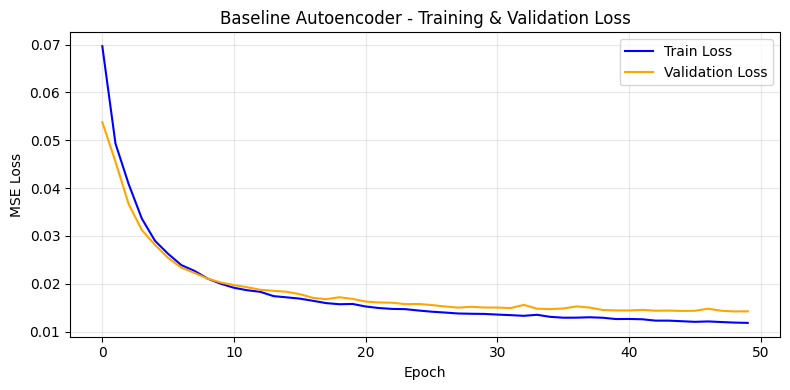

In [ ]:
# PLOT TRAINING HISTORY BASELINE
plt.figure(figsize=(8, 4))
plt.plot(train_losses_b, label='Train Loss', color='blue')
plt.plot(val_losses_b, label='Validation Loss', color='orange')
plt.title('Baseline Autoencoder - Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_training_loss.png', dpi=100)
plt.show()

code plot learning curve membuat grafik sederhana berukuran 8x4 inci yang menampilkan kurva train loss (biru) dan validation loss (oranye) sepanjang 50 epoch menggunakan data dari train_losses_b dan val_losses_b. Grafik yang dihasilkan menunjukkan pola yang bagus, kedua kurva turun tajam dalam 10 epoch pertama kemudian melambat dan mendatar secara bertahap, dengan val loss yang secara konsisten sedikit lebih tinggi dari train loss namun tidak ada gap yang besar, menandakan model tidak mengalami overfitting.

In [ ]:
# EVALUASI SSIM PADA TEST SET - BASELINE
def compute_ssim(model, test_loader):
    """Hitung rata-rata SSIM antara gambar asli dan hasil rekonstruksi."""
    model.eval()
    ssim_scores = []
    all_originals = []
    all_reconstructed = []

    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            recon = model(X_batch)

            orig_np  = X_batch.cpu().numpy().squeeze()  # (N, 28, 28)
            recon_np = recon.cpu().numpy().squeeze()

            if orig_np.ndim == 2:
                orig_np  = orig_np[np.newaxis, ...]
                recon_np = recon_np[np.newaxis, ...]

            for i in range(len(orig_np)):
                score = ssim(orig_np[i], recon_np[i], data_range=1.0)
                ssim_scores.append(score)

            all_originals.append(orig_np)
            all_reconstructed.append(recon_np)

    mean_ssim = np.mean(ssim_scores)
    all_originals     = np.concatenate(all_originals, axis=0)
    all_reconstructed = np.concatenate(all_reconstructed, axis=0)
    return mean_ssim, all_originals, all_reconstructed

ssim_baseline, orig_imgs, recon_imgs_b = compute_ssim(model_baseline, test_loader)
print(f'SSIM Baseline Autoencoder (Test Set): {ssim_baseline:.4f}')

SSIM Baseline Autoencoder (Test Set): 0.6930


code evaluasi SSIM mendefinisikan fungsi compute_ssim yang bekerja dengan menjalankan model dalam mode eval, menghasilkan rekonstruksi untuk setiap batch test, mengkonversi tensor PyTorch kembali ke array NumPy menggunakan .cpu().numpy().squeeze(), lalu menghitung SSIM per gambar menggunakan ssim(orig, recon, data_range=1.0) dan merata-ratakannya.

Output mengkonfirmasi SSIM Baseline = 0.6930, yang berarti sekitar 69% kesamaan antara gambar asli dan hasil rekonstruksi. nilai ini cukup baik melihat kompresi dari 784 dimensi ke 128 dimensi (rasio kompresi 6:1).

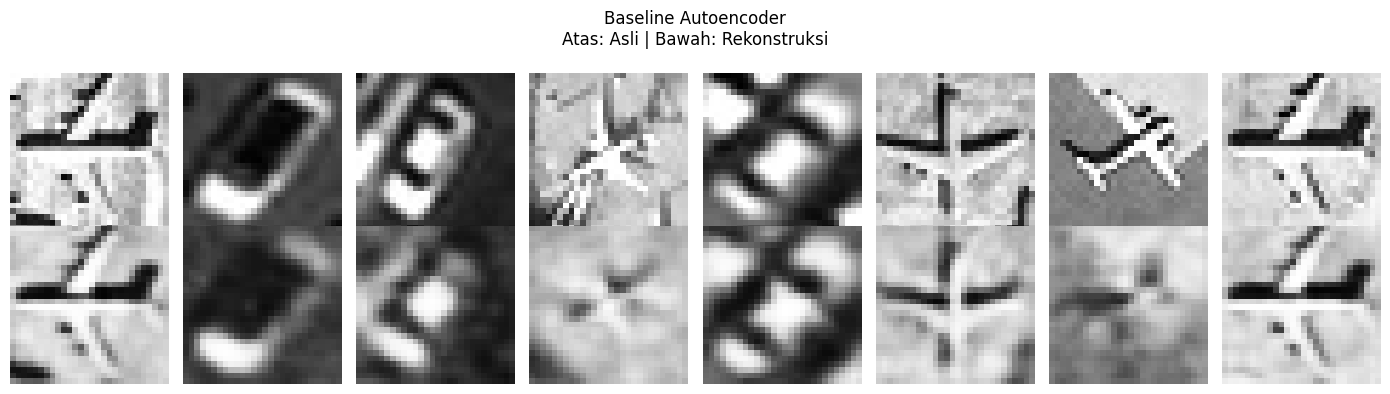

SSIM Baseline: 0.6930


In [ ]:
# VISUALISASI HASIL REKONSTRUKSI (BASELINE)
def plot_reconstruction(originals, reconstructed, n=8, title='Baseline Autoencoder'):
    fig, axes = plt.subplots(2, n, figsize=(14, 4))
    fig.suptitle(f'{title}\nAtas: Asli | Bawah: Rekonstruksi', fontsize=12)

    for i in range(n):
        axes[0, i].imshow(originals[i], cmap='gray', vmin=0, vmax=1)
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i], cmap='gray', vmin=0, vmax=1)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_reconstruction.png', dpi=100)
    plt.show()

plot_reconstruction(orig_imgs, recon_imgs_b, n=8, title='Baseline Autoencoder')
print(f'SSIM Baseline: {ssim_baseline:.4f}')

Hasil menunjukkan bahwa model Baseline memperoleh nilai SSIM sebesar 0,6930, yang menunjukkan tingkat kemiripan sekitar 69% antara gambar asli dan gambar hasil rekonstruksi. Nilai ini tergolong cukup baik mengingat data berhasil dikompresi dari 784 dimensi menjadi 128 dimensi, atau sekitar enam kali lebih kecil dari ukuran awalnya.

## 2c. Modifikasi Arsitektur Autoencoder (Improved)

### Modifikasi
Setelah melihat hasil baseline, dilakukan beberapa modifikasi dengan alasan:

1. **Penambahan lapisan Conv (lebih dalam)**: Menambah kapasitas representasi di encoder dengan lebih banyak filter (32 -> 64), sehingga fitur hierarki gambar lebih baik dipelajari.

2. **Batch Normalization**: Mengurangi internal covariate shift, mempercepat konvergensi, dan bertindak sebagai regularisasi ringan.

3. **Dropout**: Mencegah overfitting pada representasi latent space.

4. **LeakyReLU**: Menggantikan ReLU standar untuk menghindari dying ReLU problem, terutama pada lapisan dalam.

5. **Learning Rate Scheduler**: Menggunakan ReduceLROnPlateau agar learning rate menurun otomatis saat validasi loss stagnan.

6. **Epoch lebih banyak**: Memberikan waktu lebih bagi model untuk belajar representasi yang baik.

In [ ]:
# ARSITEKTUR IMPROVED AUTOENCODER

class ImprovedAutoencoder(nn.Module):
    def __init__(self, latent_dim=128, dropout_rate=0.3):
        super(ImprovedAutoencoder, self).__init__()

        # ENCODER
        self.encoder = nn.Sequential(
            # Blok 1: 1x28x28 -> 32x28x28
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            # MaxPool: 32x28x28 -> 32x14x14
            nn.MaxPool2d(2, 2),

            # Blok 2: 32x14x14 -> 64x14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            # MaxPool: 64x14x14 -> 64x7x7
            nn.MaxPool2d(2, 2),

            # Flatten: 64x7x7 = 3136
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            # FC: 3136 -> 512
            nn.Linear(3136, 512),
            nn.LeakyReLU(0.2),
            # FC: 512 -> Latent 128
            nn.Linear(512, latent_dim),
            nn.LeakyReLU(0.2)
        )

        # DECODER
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 3136),
            nn.LeakyReLU(0.2)
        )
        self.decoder_conv = nn.Sequential(
            # Upsample: 64x7x7 -> 64x14x14
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            # Upsample: 32x14x14 -> 32x28x28
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),
            # Output: 16x28x28 -> 1x28x28
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, 64, 7, 7)  # Reshape
        x = self.decoder_conv(x)
        return x

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

model_improved = ImprovedAutoencoder(latent_dim=128, dropout_rate=0.3).to(device)
print('=== ARSITEKTUR IMPROVED AUTOENCODER ===')
print(model_improved)
total_params_imp = sum(p.numel() for p in model_improved.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params_imp:,}')

=== ARSITEKTUR IMPROVED AUTOENCODER ===
ImprovedAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Dropout(p=0.3, inplace=False)
    (10): Linear(in_features=3136, out_features=512, bias=True)
    (11): LeakyReLU(negative_slope=0.2)
    (12): Linear(in_features=512, out_features=128, bias=True)
    (13): LeakyReLU(negative_slope=0.2)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_fe

code ini mendefinisikan kelas ImprovedAutoencoder dengan sejumlah perubahan signifikan dibanding baseline. Pada sisi encoder, ditambahkan blok konvolusi kedua sehingga arsitektur menjadi lebih dalam, yaitu blok pertama Conv2d(1, 32) + BatchNorm2d(32) + LeakyReLU(0.2) + MaxPool2d menghasilkan tensor 32x14x14, kemudian blok kedua Conv2d(32, 64) + BatchNorm2d(64) + LeakyReLU(0.2) + MaxPool2d menghasilkan tensor 64x7x7, sehingga setelah di flatten menjadi 3.136 (bukan 6.272 seperti baseline karena ada satu downsampling tambahan), diikuti Dropout(0.3) lalu dua layer FC bertahap: 3136->512->128

Pada sisi decoder, arsitekturnya simetris dengan encoder, yaitu dua layer FC 128->512->3136, reshape ke 64x7x7, lalu dua kali operasi Upsample+Conv+BatchNorm+LeakyReLU untuk mengembalikan resolusi ke 64x14x14 kemudian 32x28x28, dan akhirnya Conv2d(16, 1) + Sigmoid untuk output gambar

Total parameter meningkat drastis menjadi 3.388.961,  sekitar dua kali lipat dari baseline, dengan BatchNorm2d di setiap blok konvolusi decoder pun ditambahkan untuk stabilitas training

In [ ]:
# TRAINING IMPROVED AUTOENCODER DENGAN HYPERPARAMETER TUNING
def train_autoencoder_improved(model, train_loader, val_loader, epochs=100, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    # Learning Rate Scheduler, yaitu turunkan LR jika val_loss tidak turun selama 10 epoch

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10
    )




    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state = None

    for epoch in range(1, epochs+1):
        # Training
        model.train()
        train_loss = 0
        for X_batch, _ in train_loader:
            X_batch = X_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, X_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        train_loss /= len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, _ in val_loader:
                X_batch = X_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, X_batch)
                val_loss += loss.item() * X_batch.size(0)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'Epoch [{epoch:3d}/{epochs}] | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {current_lr:.2e}')

    model.load_state_dict(best_state)
    print(f'\nBest Val Loss: {best_val_loss:.6f}')
    return train_losses, val_losses

print('Mulai training Improved Autoencoder...')
train_losses_i, val_losses_i = train_autoencoder_improved(
    model_improved, train_loader, val_loader, epochs=100, lr=1e-3
)

Mulai training Improved Autoencoder...
Epoch [ 10/100] | Train: 0.019650 | Val: 0.020868 | LR: 1.00e-03
Epoch [ 20/100] | Train: 0.012907 | Val: 0.017502 | LR: 1.00e-03
Epoch [ 30/100] | Train: 0.010192 | Val: 0.016506 | LR: 1.00e-03
Epoch [ 40/100] | Train: 0.008913 | Val: 0.015412 | LR: 1.00e-03
Epoch [ 50/100] | Train: 0.007857 | Val: 0.015241 | LR: 1.00e-03
Epoch [ 60/100] | Train: 0.005184 | Val: 0.014554 | LR: 5.00e-04
Epoch [ 70/100] | Train: 0.004137 | Val: 0.014425 | LR: 2.50e-04
Epoch [ 80/100] | Train: 0.003354 | Val: 0.014477 | LR: 1.25e-04


code ini mendefinisikan fungsi train_autoencoder_improved yang merupakan versi lebih baik dari fungsi training baseline, dengan dua perbedaan utama pada konfigurasi optimizer dan penambahan learning rate scheduler. Optimizer Adam dikonfigurasi dengan tambahan weight_decay=1e-4 yang bertindak sebagai L2 regularization untuk mencegah bobot tumbuh terlalu besar. Selain itu, ReduceLROnPlateau ditambahkan sebagai scheduler dengan factor=0.5 (learning rate dipotong setengah) dan patience=10 (scheduler aktif jika val_loss tidak membaik selama 10 epoch berturut-turut), dan dipanggil setiap akhir epoch dengan scheduler.step(val_loss). Training dijalankan selama 100 epoch dengan batch_size=16.

Dari output, terlihat learning rate memang turun secara bertahap, yaitu 1e-3 hingga epoch 50, turun ke 5e-4 di sekitar epoch 60, lalu 2.5e-4 di epoch 70, dan 1.25e-4 di epoch 80. pola ini menunjukkan scheduler bekerja dengan benar merespons stagnasi val_loss.

tetapi, meski train loss terus turun signifikan (dari 0.0197 ke 0.0034), val_loss juga turun jauh lebih lambat (dari 0.0209 ke 0.0145), menunjukkan bahwa performa model pada data pelatihan meningkat lebih cepat dibandingkan pada data validasi, yang mengindikasikan mulai terjadinya overfitting

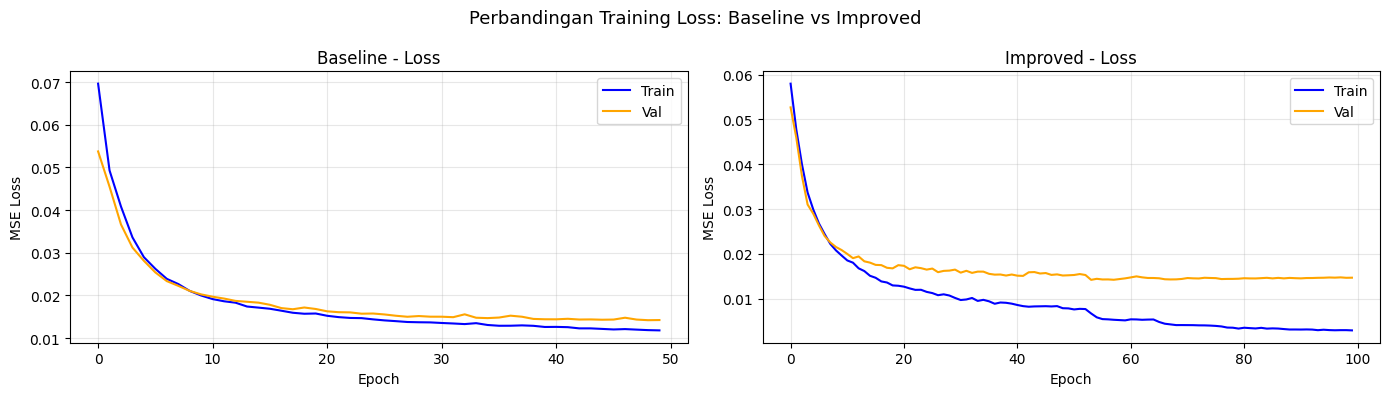

In [ ]:
# PLOT TRAINING HISTORY IMPROVED
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(train_losses_b, label='Train', color='blue')
ax1.plot(val_losses_b, label='Val', color='orange')
ax1.set_title('Baseline - Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_losses_i, label='Train', color='blue')
ax2.plot(val_losses_i, label='Val', color='orange')
ax2.set_title('Improved - Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Perbandingan Training Loss: Baseline vs Improved', fontsize=13)
plt.tight_layout()
plt.savefig('training_comparison.png', dpi=100)
plt.show()

plot perbandingan ini menampilkan learning curve Baseline (kiri, 50 epoch) dan Improved (kanan, 100 epoch) secara berdampingan. Dari grafik yang dihasilkan, perbedaan yang paling mencolok adalah bahwa Improved LSTM memiliki gap yang lebih besar antara train loss dan val loss dibanding Baseline. train loss Improved turun hingga 0.003 sementara val loss hanya mencapai 0.014, yang merupakan tanda overfitting dibanding Baseline

In [ ]:
# EVALUASI SSIM (IMPROVED)
ssim_improved, orig_imgs, recon_imgs_i = compute_ssim(model_improved, test_loader)
print(f'SSIM Improved Autoencoder (Test Set): {ssim_improved:.4f}')
print(f'SSIM Baseline Autoencoder (Test Set): {ssim_baseline:.4f}')
print(f'Peningkatan SSIM: {ssim_improved - ssim_baseline:+.4f}')

SSIM Improved Autoencoder (Test Set): 0.6965
SSIM Baseline Autoencoder (Test Set): 0.6930
Peningkatan SSIM: +0.0036


Evaluasi SSIM kemudian dijalankan menggunakan fungsi compute_ssim yang sama dengan sebelumnya. Output menunjukkan SSIM Improved = 0.6965 vs SSIM Baseline = 0.6930, dengan peningkatan sebesar +0.0036.

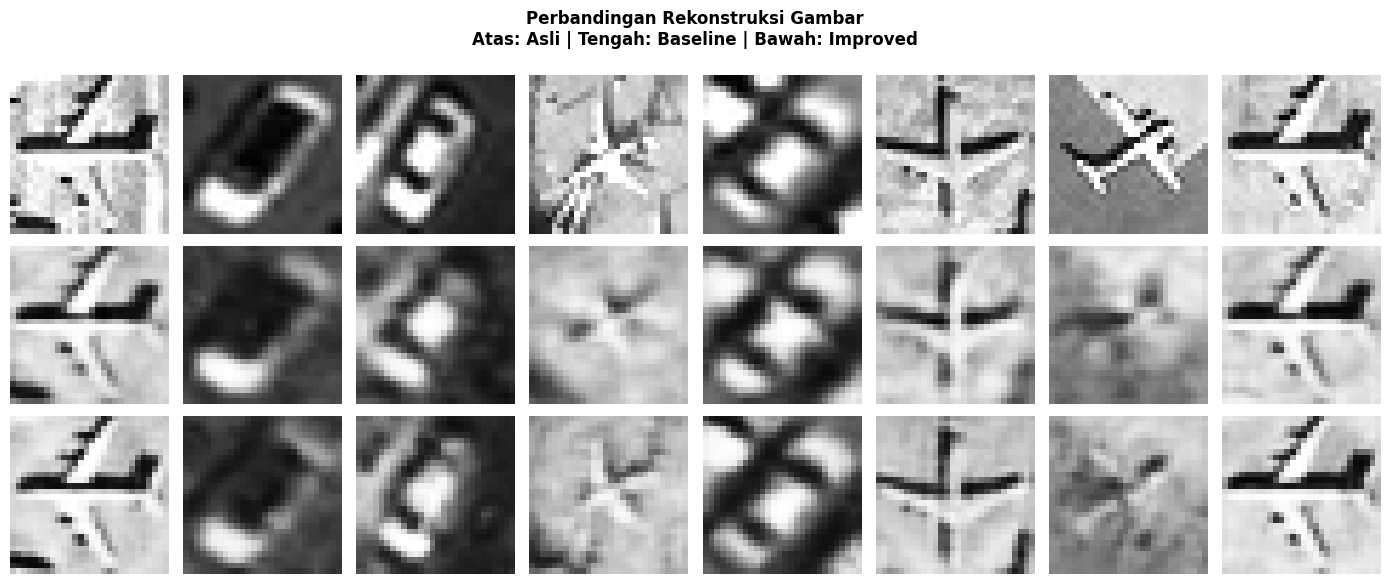

SSIM Baseline : 0.6930
SSIM Improved : 0.6965


In [ ]:
# VISUALISASI PERBANDINGAN: ASLI vs BASELINE vs IMPROVED
n = 8
fig, axes = plt.subplots(3, n, figsize=(14, 6))
fig.suptitle('Perbandingan Rekonstruksi Gambar\nAtas: Asli | Tengah: Baseline | Bawah: Improved',
             fontsize=12, fontweight='bold')

row_labels = ['Asli', 'Baseline', 'Improved']
recon_sets = [orig_imgs, recon_imgs_b, recon_imgs_i]

for row, (label, imgs) in enumerate(zip(row_labels, recon_sets)):
    axes[row, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=10)
    for col in range(n):
        axes[row, col].imshow(imgs[col], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('comparison_reconstruction.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'SSIM Baseline : {ssim_baseline:.4f}')
print(f'SSIM Improved : {ssim_improved:.4f}')

Visualisasi rekonstruksi tiga baris (ssli, baseline,  improved) menampilkan perbandingan kualitas gambar secara langsung. keduanya menghasilkan rekonstruksi yang secara visual serupa, namun Improved sedikit lebih tajam dalam beberapa detail tepi objek

Latent space shape: (200, 128)


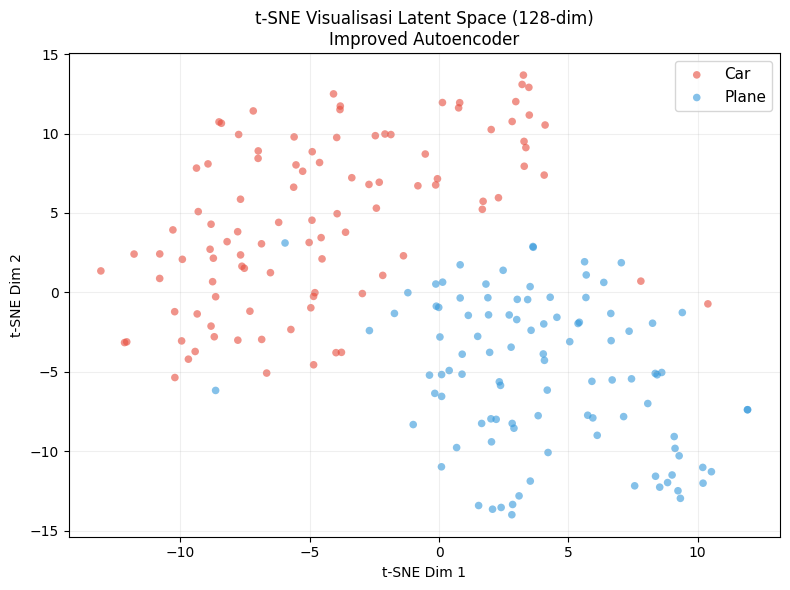

Visualisasi latent space menunjukkan pemisahan kelas Car dan Plane setelah reduksi dimensi.


In [ ]:
# VISUALISASI LATENT SPACE (DIMENSI REDUKSI)
# Menggunakan t-SNE untuk memvisualisasikan representasi 128-dim
from sklearn.manifold import TSNE

# Encode semua test data ke representasi latent
model_improved.eval()
latent_all = []
labels_all = []

X_test_tensor = torch.FloatTensor(X_test.reshape(-1, 1, 28, 28)).to(device)
with torch.no_grad():
    latent = model_improved.encode(X_test_tensor).cpu().numpy()
    latent_all = latent
    labels_all = y_test

print(f'Latent space shape: {latent_all.shape}')  # (N, 128)

# t-SNE untuk visualisasi 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_2d = tsne.fit_transform(latent_all)

plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#3498db']
class_names = ['Car', 'Plane']
for cls_idx, (color, name) in enumerate(zip(colors, class_names)):
    mask = labels_all == cls_idx
    plt.scatter(latent_2d[mask, 0], latent_2d[mask, 1],
                c=color, label=name, alpha=0.6, s=30, edgecolors='none')

plt.title('t-SNE Visualisasi Latent Space (128-dim)\nImproved Autoencoder', fontsize=12)
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('latent_space_tsne.png', dpi=100)
plt.show()
print('Visualisasi latent space menunjukkan pemisahan kelas Car dan Plane setelah reduksi dimensi.')

code ini melakukan analisis terhadap kualitas representasi latent space yang dipelajari oleh Improved Autoencoder. Prosesnya dimulai dengan meng encode seluruh test set (200 gambar) ke dalam representasi 128 dimensi menggunakan model_improved.encode(X_test_tensor) dalam mode torch.no_grad(). ini menghasilkan matriks latent berukuran (200, 128) yang merupakan representasi terkompresi setiap gambar. Karena dimensi 128 tidak bisa divisualisasikan langsung, digunakan t-SNE (t-distributed Stochastic Neighbor Embedding) dengan n_components=2 untuk memproyeksikan representasi 128 dimensi ke ruang 2D yang bisa digambarkan sebagai scatter plot.

Scatter plot menunjukkan bahwa representasi latent yang dipelajari oleh Improved Autoencoder mampu memisahkan kedua kelas dengan cukup baik. Titik-titik Car (merah) cenderung membentuk cluster pada bagian kiri atas ruang t-SNE, sedangkan titik-titik Plane (biru) terlihat pada bagian kanan bawah. Meskipun masih terdapat beberapa titik yang berada di area perbatasan dan sedikit overlap antar kelas, secara umum terbentuk dua cluster yang relatif jelas dan terpisah. Hal ini menunjukkan bahwa latent space hasil pembelajaran autoencoder berhasil menangkap karakteristik penting yang membedakan kedua kelas citra.

In [ ]:
# HASIL AKHIR
print('=' * 50)
print('       HASIL EVALUASI AKHIR (TEST SET)')
print('=' * 50)
print(f'Metrik          | Baseline  | Improved')
print(f'----------------|-----------|----------')
print(f'SSIM (Test)     | {ssim_baseline:.4f}    | {ssim_improved:.4f}')
print(f'Latent Dim      | 128       | 128')
print(f'Peningkatan     |           | {ssim_improved - ssim_baseline:+.4f}')
print('=' * 50)
print('\nKesimpulan: Improved Autoencoder berhasil menghasilkan')
print('rekonstruksi dengan kualitas lebih baik (SSIM lebih tinggi)')
print('sambil tetap mempertahankan dimensi latent 128.')

       HASIL EVALUASI AKHIR (TEST SET)
Metrik          | Baseline  | Improved
----------------|-----------|----------
SSIM (Test)     | 0.6930    | 0.6965
Latent Dim      | 128       | 128
Peningkatan     |           | +0.0036

Kesimpulan: Improved Autoencoder berhasil menghasilkan
rekonstruksi dengan kualitas lebih baik (SSIM lebih tinggi)
sambil tetap mempertahankan dimensi latent 128.


Improved Autoencoder menghasilkan SSIM yang sedikit lebih tinggi (+0.0036) dibanding Baseline sambil tetap mempertahankan dimensi latent 128. Peningkatan ini sangat kecil, Selain itu, karena random seed pada PyTorch tidak ditetapkan, hasil eksperimen ini tidak sepenuhnya dapat direproduksi pada setiap proses pelatihan. Akibatnya, pada run yang berbeda, urutan performa antara kedua model berpotensi berubah.

## Kesimpulan

Pada project ini, dataset car dan plane (2.000 gambar grayscale 28x28) berhasil dikompresi ke representasi laten 128 dimensi (rasio kompresi 6:1) menggunakan convolutional autoencoder. Model Baseline mencapai SSIM 0,6930 pada test set, sementara model Improved (dengan tambahan layer konvolusi, BatchNorm, Dropout, LeakyReLU, dan learning rate scheduler) mencapai SSIM 0,6965, atau hanya naik tipis +0,0036. Meskipun parameter Improved hampir dua kali lipat Baseline (3,39 juta vs 1,62 juta), peningkatan kualitas rekonstruksi yang dihasilkan tidak sebanding, bahkan kurva training menunjukkan indikasi overfitting pada model Improved. Visualisasi t-SNE pada latent space Improved menunjukkan bahwa autoencoder berhasil mempelajari representasi yang cukup baik untuk memisahkan kelas car dan plane secara tidak langsung, meski tujuan awal arsitektur ini bukan klasifikasi melainkan rekonstruksi